In [1]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
import plotly.express as px
%matplotlib inline

In [2]:
sd = pd.read_csv("data/student_habits_performance.csv")

In [3]:
def convert_to_letter_grade(score):
    if score >= 80:
        return 'A'
    elif score >= 70:
        return 'B'
    elif score >= 60:
        return 'C'
    elif score >= 50:
        return 'D'
    else:
        return 'F'

sd['grade'] = sd['exam_score'].apply(convert_to_letter_grade)

In [4]:
sd['risk_status'] = sd['grade'].apply(lambda x: 'AtRisk' if x in ['D', 'F'] else 'NotAtRisk')

In [5]:
# Separate the target variable (risk_status) from the feature set
sd_y = sd['risk_status']
sd_X = sd[sd.columns.difference(['risk_status'])]

In [6]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder, StandardScaler, LabelEncoder
from feature_engine.discretisation import DecisionTreeDiscretiser
from sklearn.impute import SimpleImputer
from imblearn.over_sampling import BorderlineSMOTE
from sklearn.feature_selection import SelectFromModel
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
import pandas as pd
import adsa_utils as ad 

8 features were selected by XGBoost using embedded feature selection:
['exercise_frequency', 'mental_health_rating', 'netflix_hours', 'part_time_job', 'sleep_hours', 'social_media_hours', 'study_hours_per_day', 'media_usage_hours_pca']
Fitting 5 folds for each of 300 candidates, totalling 1500 fits
Best parameters found: {'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 0.5, 'max_depth': 6, 'bootstrap': True}
Mean Accuracy is 93.84 +/- 0.87
Mean Precision is 94.03 +/- 0.74
Mean Recall is 93.84 +/- 0.87
Mean F-score is 93.83 +/- 0.88
              precision    recall  f1-score   support

      AtRisk       0.76      0.84      0.80        56
   NotAtRisk       0.93      0.90      0.91       144

    accuracy                           0.88       200
   macro avg       0.85      0.87      0.86       200
weighted avg       0.89      0.88      0.88       200



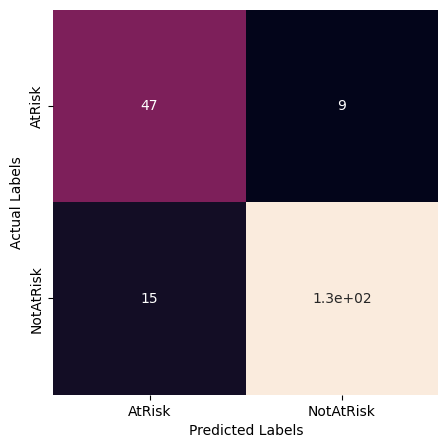

In [7]:
# PCA on original numerical data ---
sd_XX = sd_X.copy()
pca = PCA(n_components=1)
sd_XX['media_usage_hours_pca'] = pca.fit_transform(sd_XX[['social_media_hours', 'netflix_hours']])

# Drop leakage columns
sd_XX.drop(columns=['student_id', 'exam_score', 'grade'], inplace=True)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    sd_XX, sd_y, test_size=0.2, random_state=43, stratify=sd_y
)

# DecisionTree binning
dt_binner = DecisionTreeDiscretiser(
    bin_output='boundaries',
    cv=5,
    precision=2,
    scoring='accuracy',
    regression=False,
    random_state=43,
    param_grid={'max_depth': [3, 4, 5, 6], 'ccp_alpha': [0.0, 0.005, 0.01]}
)

X_train_binned = dt_binner.fit_transform(X_train, y_train)
X_test_binned = dt_binner.transform(X_test)
X_train = pd.DataFrame(X_train_binned)
X_test = pd.DataFrame(X_test_binned)

# Categorical processing 
cat_cols = X_train.select_dtypes(include=['object']).columns.tolist()
preprocessor = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder())
])
X_train = pd.DataFrame(preprocessor.fit_transform(X_train[cat_cols]), columns=cat_cols)
X_test  = pd.DataFrame(preprocessor.transform(X_test[cat_cols]), columns=cat_cols)

# BorderlineSMOTE to handle class imbalance
smote = BorderlineSMOTE(random_state=43, k_neighbors=5, m_neighbors=10)
X_train, y_train = smote.fit_resample(X_train, y_train)

# Apply standard scaling
scaler = StandardScaler()
X_train = pd.DataFrame(scaler.fit_transform(X_train), columns=cat_cols)
X_test = pd.DataFrame(scaler.transform(X_test), columns=cat_cols)

# Encode the target labels for the final model
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)
## Make y_train and y_test pandas Series again
y_train = pd.Series(y_train_encoded)
y_test = pd.Series(y_test_encoded)


# Feature Selection: XGBoost
xgb_selector = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=43
)

sfm = SelectFromModel(estimator=xgb_selector, threshold='median')
X_train_selected = sfm.fit_transform(X_train, y_train)
X_test_selected = sfm.transform(X_test)
selected_features = [cat_cols[i] for i in sfm.get_support(indices=True)]
print(f"{len(selected_features)} features were selected by XGBoost using embedded feature selection:\n{selected_features}")
X_train = pd.DataFrame(X_train_selected, columns=selected_features)
X_test = pd.DataFrame(X_test_selected, columns=selected_features)

# Random Forest classifier
clf = RandomForestClassifier(n_estimators=100, random_state=43)
param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 4, 5, 6],
    'max_features': ['sqrt', 0.5, 0.7],
    'min_samples_split': [3, 5, 7, 9],
    'min_samples_leaf': [2, 4, 6],
    'bootstrap': [True, False]
}
stratified_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=43)
random_search = RandomizedSearchCV(
    clf,
    param_distributions=param_dist,
    n_iter=300,
    cv=stratified_cv,
    verbose=1,
    random_state=43,
    n_jobs=-1
)
random_search.fit(X_train, y_train)

# Evaluation
print(f'Best parameters found: {random_search.best_params_}')
best_clf_rf = random_search.best_estimator_

ad.cross_validation_avg_scores(X_train, y_train, best_clf_rf, cv_=5, print_dict=False)
y_pred_encoded = best_clf_rf.predict(X_test)
y_pred = label_encoder.inverse_transform(y_pred_encoded)
y_test = label_encoder.inverse_transform(y_test)

print(ad.classification_report(y_test, y_pred))
ad.plot_save_confusion_matrix(y_test, y_pred, "confusion_matrix_rf")

In [8]:
from sklearn.tree import export_text, plot_tree
import matplotlib.pyplot as plt

# Choose one tree from the forest
best_clf_rf_tree = best_clf_rf.estimators_[1]

depth = best_clf_rf_tree.get_depth()
n_leaves = best_clf_rf_tree.get_n_leaves()

print(f"The selected decision tree has a depth of {depth} and {n_leaves} leaves.")

The selected decision tree has a depth of 6 and 31 leaves.


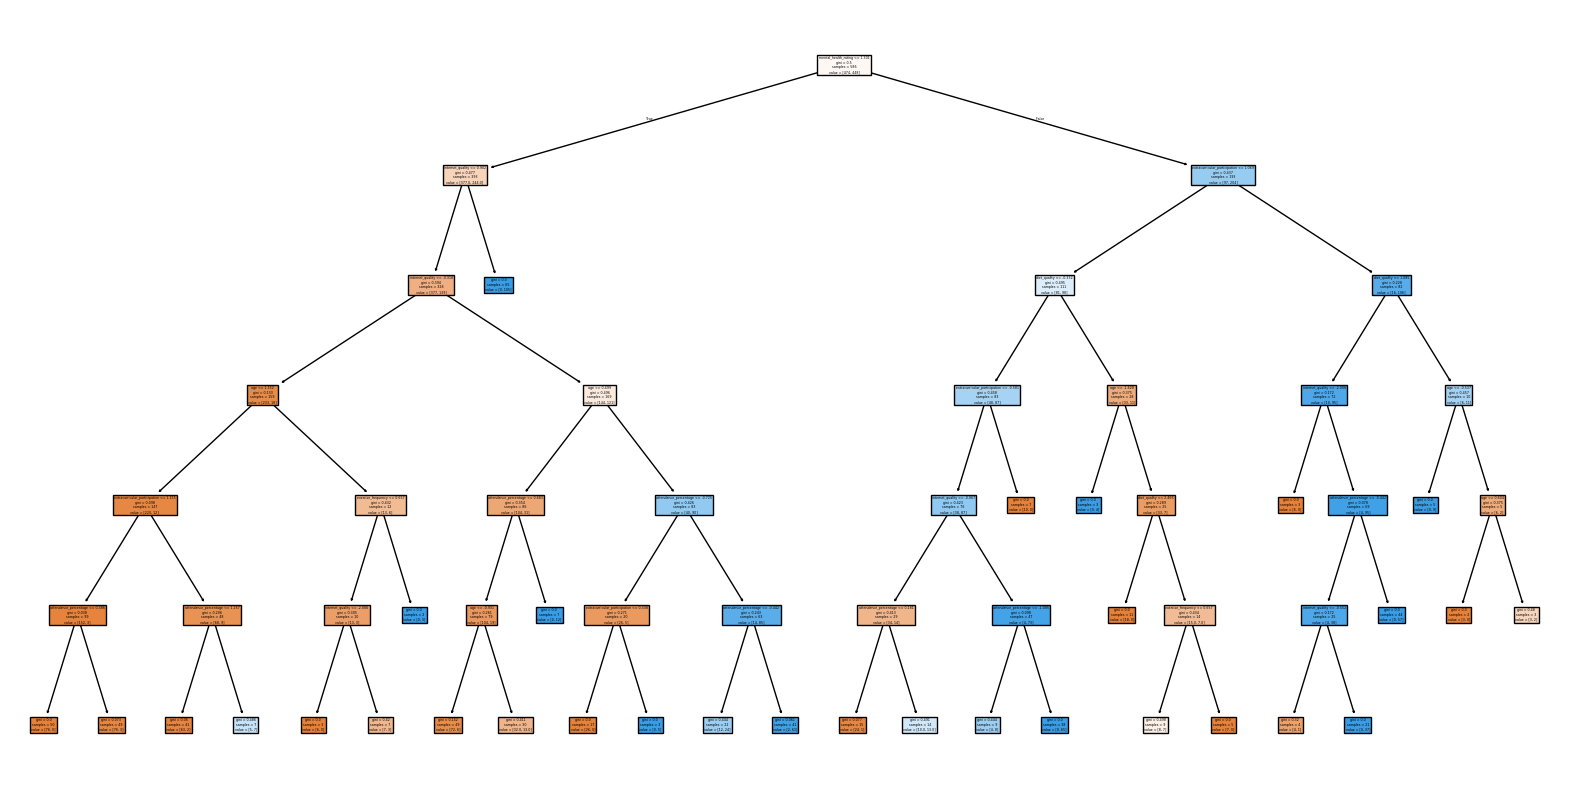

In [9]:
plt.figure(figsize=(20, 10))
plot_tree(best_clf_rf_tree, feature_names=cat_cols, filled=True, rounded=False)
plt.savefig("img/decision_tree_rf.png", bbox_inches='tight')  # Save the figure
plt.show()

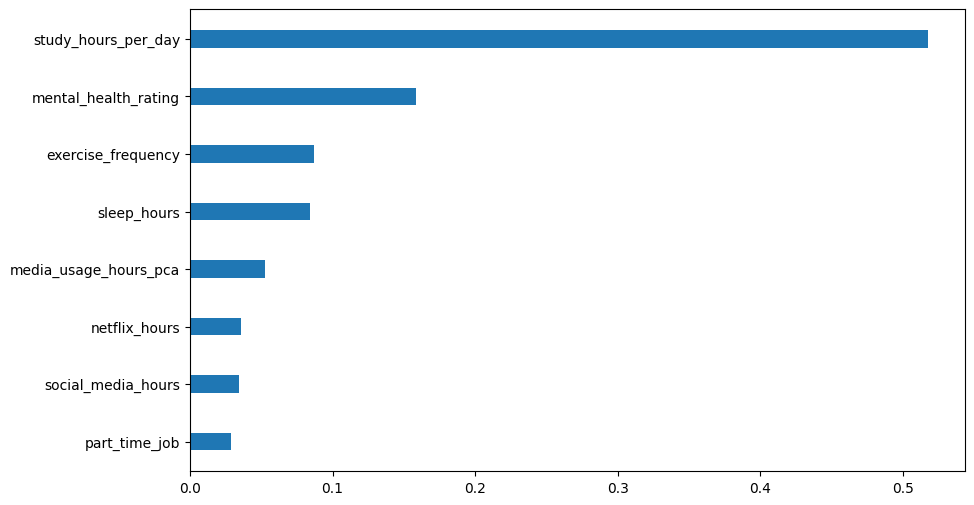

Feature importances (descending order):
study_hours_per_day: 0.5178
mental_health_rating: 0.1583
exercise_frequency: 0.0871
sleep_hours: 0.0845
media_usage_hours_pca: 0.0527
netflix_hours: 0.0360
social_media_hours: 0.0345
part_time_job: 0.0291


In [10]:
import matplotlib.pyplot as plt
import numpy as np

# After RandomizedSearchCV and selecting the best model
best_clf_rf = random_search.best_estimator_

# Get feature importances from the trained RandomForest model
importances = best_clf_rf.feature_importances_

# Get the feature names already selected
selected_featuress = X_train.columns  # X_train already has selected features!

# Sort the feature importances in descending order
indices = np.argsort(importances)[::-1]

# Plot the feature importances horizontally with reduced bar thickness
plt.figure(figsize=(10, 6))
#plt.title("Feature Importance")
plt.barh(range(len(selected_featuress)), importances[indices], align="center", height=0.3)  # Adjust the bar thickness here
plt.yticks(range(len(selected_featuress)), selected_featuress[indices])
plt.gca().invert_yaxis()  # Invert the y-axis to have the most important feature at the top
plt.savefig('img/feature_importance_rf.png', dpi=300, bbox_inches='tight')
plt.show()

print("Feature importances (descending order):")
for i in indices:
    print(f"{selected_featuress[i]}: {importances[i]:.4f}")

8 features were selected by XGBoost using embedded feature selection:
['exercise_frequency', 'mental_health_rating', 'netflix_hours', 'part_time_job', 'sleep_hours', 'social_media_hours', 'study_hours_per_day', 'media_usage_hours_pca']
Fitting 5 folds for each of 500 candidates, totalling 2500 fits
Best parameters found: {'subsample': 0.6, 'reg_lambda': 2, 'reg_alpha': 1, 'n_estimators': 400, 'min_child_weight': 3, 'max_depth': 6, 'learning_rate': 0.05, 'gamma': 1, 'colsample_bytree': 0.7}
Mean Accuracy is 94.79 +/- 0.47
Mean Precision is 94.86 +/- 0.48
Mean Recall is 94.79 +/- 0.47
Mean F-score is 94.79 +/- 0.47
              precision    recall  f1-score   support

      AtRisk       0.82      0.84      0.83        56
   NotAtRisk       0.94      0.93      0.93       144

    accuracy                           0.91       200
   macro avg       0.88      0.88      0.88       200
weighted avg       0.91      0.91      0.91       200



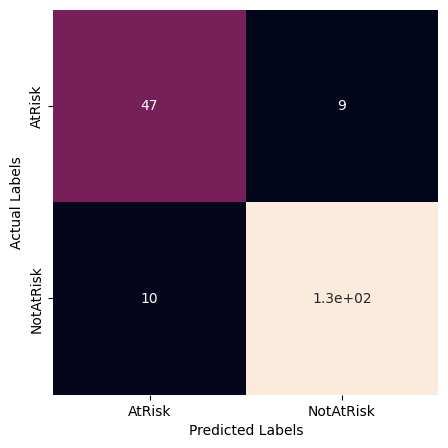

In [12]:
# PCA on original numerical data ---
sd_XX = sd_X.copy()
pca = PCA(n_components=1)
sd_XX['media_usage_hours_pca'] = pca.fit_transform(sd_XX[['social_media_hours', 'netflix_hours']])

# Drop leakage columns
sd_XX.drop(columns=['student_id', 'exam_score', 'grade'], inplace=True)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    sd_XX, sd_y, test_size=0.2, random_state=43, stratify=sd_y
)

# DecisionTree binning
dt_binner = DecisionTreeDiscretiser(
    bin_output='boundaries',
    cv=5,
    precision=2,
    scoring='accuracy',
    regression=False,
    random_state=43,
    param_grid={'max_depth': [3, 4, 5, 6], 'ccp_alpha': [0.0, 0.005, 0.01]}
)

X_train_binned = dt_binner.fit_transform(X_train, y_train)
X_test_binned = dt_binner.transform(X_test)
X_train = pd.DataFrame(X_train_binned)
X_test = pd.DataFrame(X_test_binned)

# Categorical processing 
cat_cols = X_train.select_dtypes(include=['object']).columns.tolist()
preprocessor = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder())
])
X_train = pd.DataFrame(preprocessor.fit_transform(X_train[cat_cols]), columns=cat_cols)
X_test  = pd.DataFrame(preprocessor.transform(X_test[cat_cols]), columns=cat_cols)

# BorderlineSMOTE to handle class imbalance
smote = BorderlineSMOTE(random_state=43, k_neighbors=5, m_neighbors=10)
X_train, y_train = smote.fit_resample(X_train, y_train)

# Apply standard scaling
scaler = StandardScaler()
X_train = pd.DataFrame(scaler.fit_transform(X_train), columns=cat_cols)
X_test = pd.DataFrame(scaler.transform(X_test), columns=cat_cols)

# Encode the target labels for the final model
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)
## Make y_train and y_test pandas Series again
y_train = pd.Series(y_train_encoded)
y_test = pd.Series(y_test_encoded)


# Feature Selection: XGBoost
X_train_selected = sfm.fit_transform(X_train, y_train)
X_test_selected = sfm.transform(X_test)
selected_features = [cat_cols[i] for i in sfm.get_support(indices=True)]
print(f"{len(selected_features)} features were selected by XGBoost using embedded feature selection:\n{selected_features}")
X_train = pd.DataFrame(X_train_selected, columns=selected_features)
X_test = pd.DataFrame(X_test_selected, columns=selected_features)

# XGBoost classifier
clf = XGBClassifier(
    random_state=43,
    eval_metric='logloss',
)

# Hyperparameter space for XGBoost (for RandomizedSearchCV)
param_dist = {
    'n_estimators': np.arange(100, 701, 100),  # Reduce upper limit to avoid too many trees
    'max_depth': [3, 4, 5, 6, 7],              # Shallow trees generalize better
    'learning_rate': [0.01, 0.05, 0.1],        # Smaller values for smoother learning
    'subsample': [0.6, 0.7, 0.8],              # Avoid overfitting by using row sampling
    'colsample_bytree': [0.6, 0.7, 0.8],       # Avoid overfitting by using feature sampling
    'gamma': [0.1, 0.3, 0.5, 1],               # Minimum gain needed to split a node (adds pruning)
    'min_child_weight': [3, 5, 7],             # Minimum sum of instance weight in a child (larger = more conservative)
    'reg_alpha': [0.01, 0.1, 1],               # L1 regularization
    'reg_lambda': [1, 2, 5]                    # L2 regularization
}


# Define the Stratified K-Fold cross-validator
stratified_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=43)

# RandomizedSearchCV for hyperparameter tuning
random_search = RandomizedSearchCV(
    clf, param_distributions=param_dist, 
    n_iter=500, 
    cv=stratified_cv, 
    verbose=1, 
    random_state=43, 
    n_jobs=-1
)

# Evaluation
random_search.fit(X_train, y_train)
# Print best hyperparameters
print(f'Best parameters found: {random_search.best_params_}')

best_clf_xgb = random_search.best_estimator_
ad.cross_validation_avg_scores(X_train, y_train, best_clf_xgb, cv_=5, print_dict=False)
y_pred = best_clf_xgb.predict(X_test)

# Decode the predictions and true values back to the original labels
y_pred = label_encoder.inverse_transform(y_pred)
y_test = label_encoder.inverse_transform(y_test)

# Report and Confusion Matrix
print(ad.classification_report(y_test, y_pred))
ad.plot_save_confusion_matrix(y_test, y_pred, "confusion_matrix_xgb")

In [13]:
from xgboost import Booster

booster = best_clf_xgb.get_booster()
model_dump = booster.get_dump(with_stats=True)
tree = model_dump[1].split('\n')
depth = max(line.count('\t') for line in tree if line.strip() != '')
n_leaves = sum(1 for line in tree if 'leaf=' in line)
print(f"The first XGBoost tree has a depth of {depth} and {n_leaves} leaves.")

The first XGBoost tree has a depth of 5 and 9 leaves.


<Figure size 2000x2400 with 0 Axes>

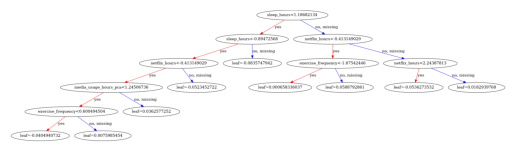

In [14]:
# Plot the first tree from the trained XGBoost model (num_trees=0 is the first tree)
import matplotlib.pyplot as plt
from xgboost import plot_tree

plt.figure(figsize=(20, 24))  # This makes the plot larger

# Plot the first tree from the trained XGBoost model
plot_tree(best_clf_xgb, num_trees=1, rankdir='TB')  # You can adjust the num_trees parameter as needed

# Save the plot as a PNG file with tight bounding box to minimize white space
plt.savefig('img/decision_tree_plot.png', dpi=300, bbox_inches='tight')

# Optionally, you can also display the plot inline
plt.show()

<Figure size 1200x1600 with 0 Axes>

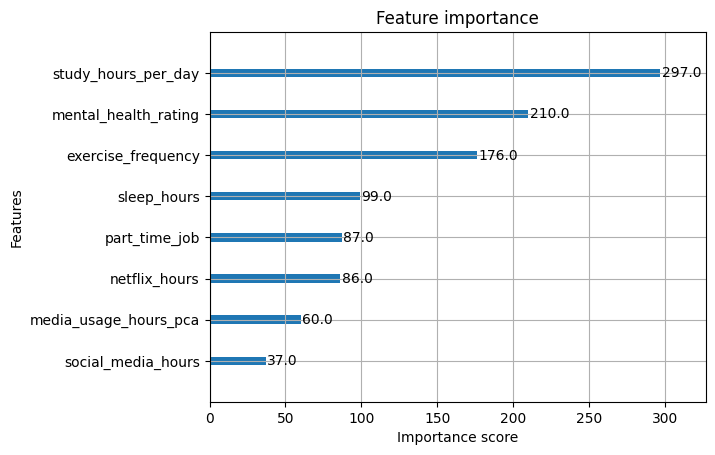

study_hours_per_day: 297.0
mental_health_rating: 210.0
exercise_frequency: 176.0
sleep_hours: 99.0
part_time_job: 87.0
netflix_hours: 86.0
media_usage_hours_pca: 60.0
social_media_hours: 37.0


In [15]:
import matplotlib.pyplot as plt
import xgboost as xgb

# Plot the feature importance
plt.figure(figsize=(12,16))  # Adjust the size as needed
xgb.plot_importance(best_clf_xgb, importance_type='weight', max_num_features=14)

# Save the plot as a PNG file with tight bounding box to minimize white space
plt.savefig('img/feature_importance_xgb.png', dpi=300, bbox_inches='tight')
plt.show()

# Get feature importance scores (using 'weight', 'gain', or 'cover')
importance_dict = booster.get_score(importance_type='weight')

# Sort features by importance descending
sorted_features = sorted(importance_dict.items(), key=lambda x: x[1], reverse=True)

# print("Feature importances (descending order):")
for feature, score in sorted_features:
    print(f"{feature}: {score}")

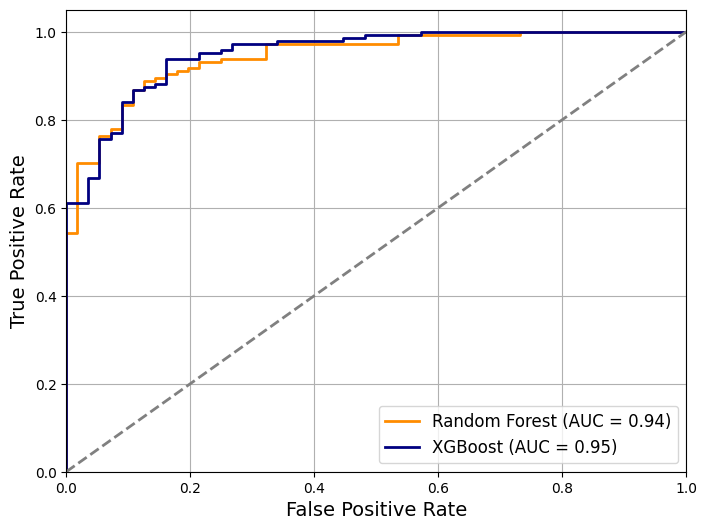

In [17]:
from sklearn.metrics import roc_curve, auc

# Get probability predictions for positive class
y_score_rf = best_clf_rf.predict_proba(X_test)[:, 1]
y_score_xgb = best_clf_xgb.predict_proba(X_test)[:, 1]

# Compute ROC and AUC
fpr_rf, tpr_rf, _ = roc_curve(y_test_encoded, y_score_rf)
roc_auc_rf = auc(fpr_rf, tpr_rf)

fpr_xgb, tpr_xgb, _ = roc_curve(y_test_encoded, y_score_xgb)
roc_auc_xgb = auc(fpr_xgb, tpr_xgb)

# Plot ROC curves
plt.figure(figsize=(8, 6))
plt.plot(fpr_rf, tpr_rf, color='darkorange', lw=2, label=f'Random Forest (AUC = {roc_auc_rf:.2f})')
plt.plot(fpr_xgb, tpr_xgb, color='navy', lw=2, label=f'XGBoost (AUC = {roc_auc_xgb:.2f})')
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
plt.xlim([0, 1])
plt.ylim([0, 1.05])
plt.xlabel('False Positive Rate', fontsize=14)
plt.ylabel('True Positive Rate', fontsize=14)
#plt.title('ROC Curve Comparison', fontsize=16)
plt.legend(loc='lower right', fontsize=12)
plt.grid(True)
plt.savefig("img/roc_curve.png")
plt.show()

# Association